In [1]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'src' folder
project_root = Path.cwd()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'src' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies


In [2]:
from src.data import load_simple_price_csv
from src.core import Asset, Capital, FixedRiskSizer
from src.engine import BacktestRunner, Portfolio, PerformanceAnalyzer
from src.strategies import BuyAndHoldStrategy

In [3]:
COMISSION = 0.0004
SLIPPAGE = 0.001
data1 = load_simple_price_csv("../data/MCFTR.csv")
data2 = load_simple_price_csv("../data/GLDRUB_TOM.csv")
MCFTR = Asset(ticker= 'MCFTR', price_data=data1, commission_rate=COMISSION, slippage_rate=SLIPPAGE)
GOLD = Asset(ticker= 'GLDRUB', price_data=data2, commission_rate=COMISSION, slippage_rate=SLIPPAGE)

In [4]:
INITIAL_CAPITAL = 100_000
VOLATILITY_WINDOW = 252
RISK_TARGET = 0.1
MAX_LEVERAGE = 1.0

In [5]:
risk_sizer = FixedRiskSizer(
    volatility_window=VOLATILITY_WINDOW, 
    risk_target=RISK_TARGET, 
    expected_sharpe=1, 
    max_leverage=MAX_LEVERAGE
)

# 2. Define Capital
capital = Capital(initial_capital=INITIAL_CAPITAL)

# 3. Initialize Runner and Run
runner1 = BacktestRunner(capital=capital, asset=MCFTR, sizer=risk_sizer)
runner2 = BacktestRunner(capital=capital, asset=GOLD, sizer= risk_sizer)
stock_result = runner1.run(BuyAndHoldStrategy())
gold_result = runner2.run(BuyAndHoldStrategy())

In [6]:
stock_result.print_summary()


════════════════════════════════════════════════════════════
  STRATEGY SUMMARY: Buy and Hold
════════════════════════════════════════════════════════════
  Years:             22.97
  Total Return:      +140.67%
  CAGR:              +6.13%
  Gross Return:      +144.99%
------------------------------------------------------------
  Annual Volatility: 11.04%
  Max Drawdown:      -32.23%
  Avg Drawdown:      -2.12%
------------------------------------------------------------
  Sharpe Ratio:      0.55
  Gross Sharpe:      0.57
  Sortino Ratio:     0.65
------------------------------------------------------------
  Total Fees:        $4,325.32
  Fee Drag Ratio:    0.03
════════════════════════════════════════════════════════════



In [7]:
from src.visualization import print_report_comparison
print_report_comparison(title="BH strategies", reports={"gold": gold_result, "stock": stock_result})


──────────────────────┬────────────┬────────────┐
│               BH strategies                │
├──────────────────────┼────────────┼────────────┤
│Metric                │       gold │      stock │
├──────────────────────┼────────────┼────────────┤
│ 📅 Period                                   │
├──────────────────────┼────────────┼────────────┤
│Years                 │      12.43 │      22.97 │
├──────────────────────┼────────────┼────────────┤
│  Returns & Performance                     │
├──────────────────────┼────────────┼────────────┤
│Total Return %        │   +147.12% │   +140.67% │
│CAGR %                │    +11.84% │     +6.13% │
│Gross Return %        │   +149.49% │   +144.99% │
├──────────────────────┼────────────┼────────────┤
│ ⚠️ Risk & Volatility                       │
├──────────────────────┼────────────┼────────────┤
│Annual Vol %          │    +11.11% │    +11.04% │
│Max Drawdown %        │    -24.49% │    -32.23% │
│Avg Drawdown %        │     -2.60% │     -2.12

In [8]:
portfolio = Portfolio(results={"gold": gold_result.result, "stock": stock_result.result}, weights=[0.5, 0.5])

In [9]:
from src.visualization import print_portfolio_diversification, print_summary, plot_backtest_results
print_portfolio_diversification(portfolio)


════════════════════════════════════════════════════════════
  PORTFOLIO DIVERSIFICATION ANALYSIS
════════════════════════════════════════════════════════════

  Diversification Ratio:        1.55
  Volatility Reduction:        35.5%

  Correlation Matrix:
────────────────────────────────────────────────────────────
         gold  stock
  gold   1.00  -0.17
  stock -0.17   1.00
════════════════════════════════════════════════════════════



In [10]:
portfolio_result = PerformanceAnalyzer(Capital()).analyze(portfolio)

In [11]:
print_summary(strategy_name="portfolio", metrics=portfolio_result)


════════════════════════════════════════════════════════════
  STRATEGY SUMMARY: portfolio
════════════════════════════════════════════════════════════
  Years:             12.31
  Total Return:      +109.34%
  CAGR:              +8.88%
  Gross Return:      +112.67%
------------------------------------------------------------
  Annual Volatility: 6.99%
  Max Drawdown:      -13.43%
  Avg Drawdown:      -1.21%
------------------------------------------------------------
  Sharpe Ratio:      1.27
  Gross Sharpe:      1.31
  Sortino Ratio:     1.73
------------------------------------------------------------
  Total Fees:        $3,332.49
  Fee Drag Ratio:    0.03
════════════════════════════════════════════════════════════



c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\visualization\plotter.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


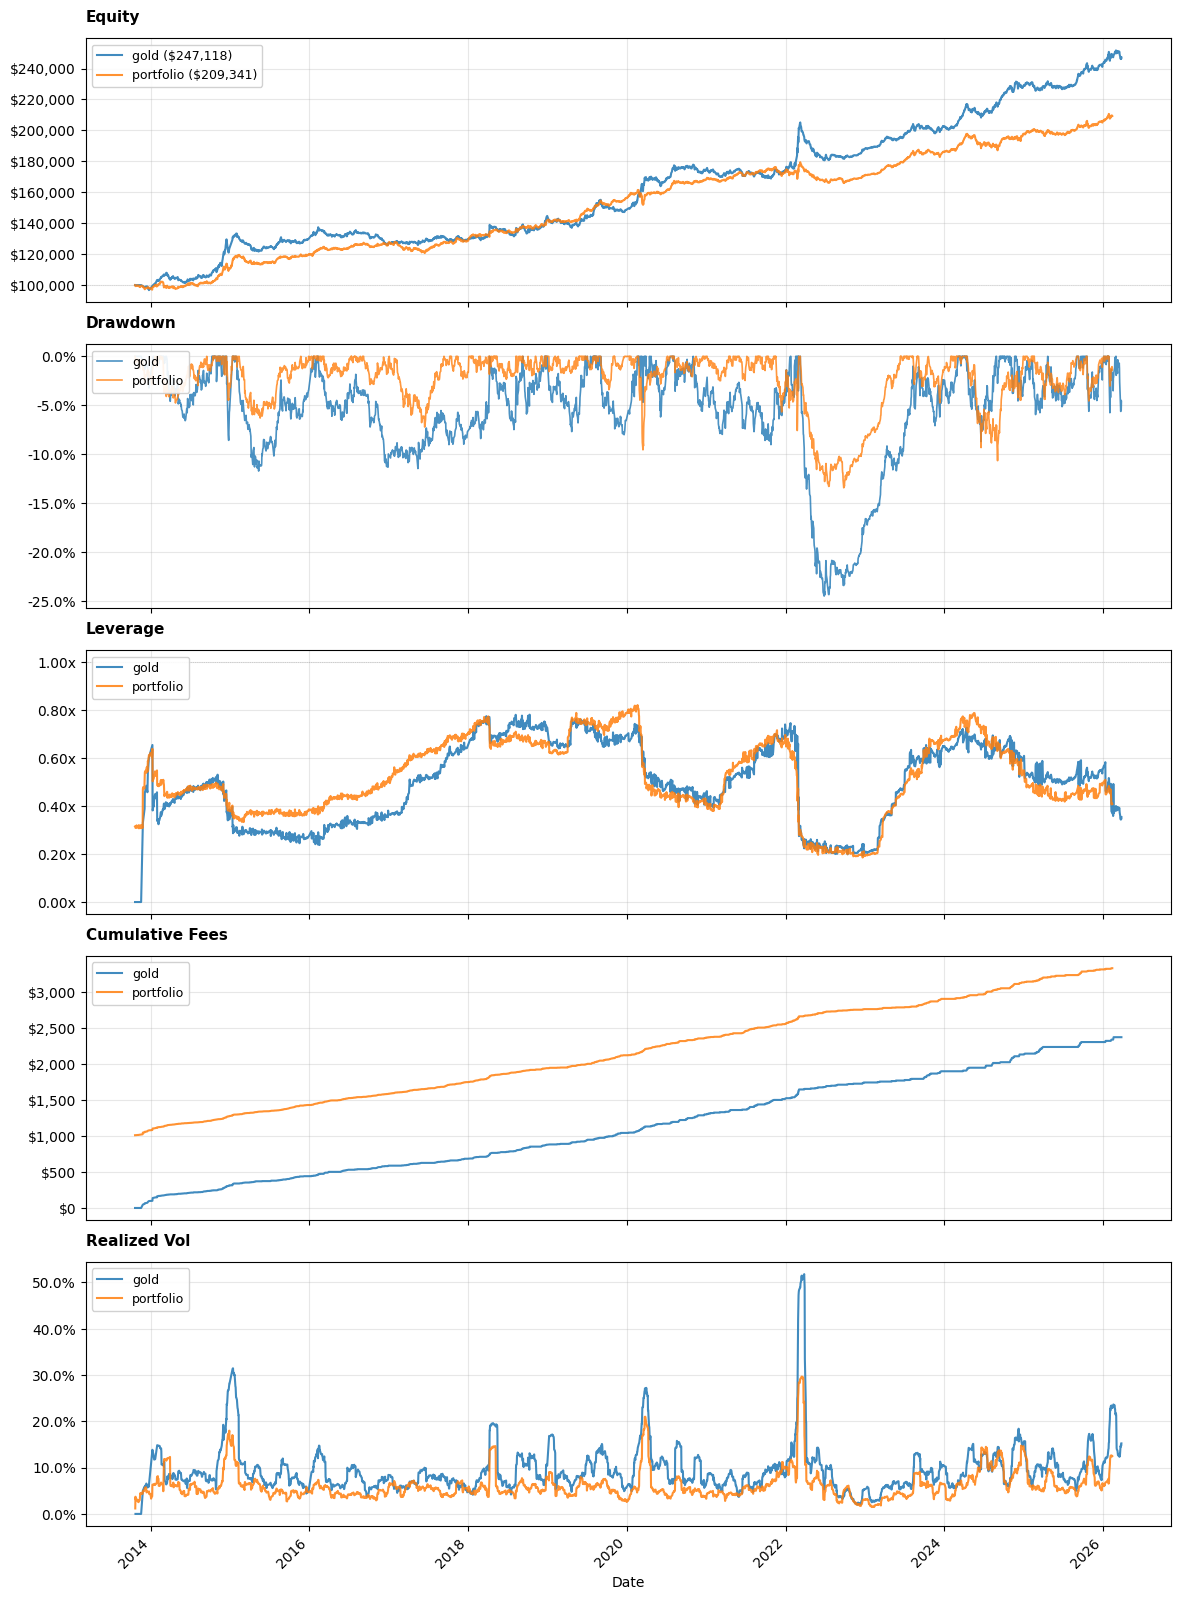

In [12]:
plot_backtest_results(results={"gold": gold_result.result, "portfolio": portfolio})